In [1]:
import numpy as np
import umap
_dataset_path = "qd/datasets/track_embeddings_metrics_32dim_rngMixDS_tita_circular_7.npz"
EMBEDDING_MODEL_PATH = "qd/pretrained_models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_circular_7.pth"
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]

umap_model = umap.UMAP(n_components=2, random_state=67)
umap_model.fit(_embeddings)

d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,n_neighbors,15
,n_components,2
,metric,'euclidean'
,metric_kwds,None
,output_metric,'euclidean'
,output_metric_kwds,None
,n_epochs,None
,learning_rate,1.0
,init,'spectral'
,min_dist,0.1
,spread,1.0


In [2]:
# Generate and evaluate multiple tracks plus mutated variants
import requests
import random
import copy

randomizer = random.Random(100)
num_tracks = 10
seed_candidates = randomizer.sample(range(1, 10000), num_tracks)

def generate_track(seed, randomizer):
    response = requests.post(
        "http://localhost:4242/generate",
        json={
            "id": seed,
            "mode": "voronoi",
            "trackSize": randomizer.randint(4, 10),
            "rngMode": 0,
        },
        timeout=60,
    )

    if not response.ok:
        raise Exception(f"API error {response.status_code}: {response.text}")

    sol = response.json()
    sol["rngMode"] = 1
    return sol

def mutate_track(sol_in, intensity, randomizer):
    # deep copy sol
    sol = copy.deepcopy(sol_in)

    seed = sol["id"]
    response = requests.post(
                    f"http://localhost:4242/mutate",
                    json={
                        "individual": sol,
                        "intensityMutation": intensity, # Constant mutation intensity
                        "genetic_seed": seed
                    },
                    timeout=60
                )
    if not response.ok:
                    raise Exception(f"API error {response.status_code}: {response.text}")
    mutated = response.json().get("mutated", {})
    print("Mutated track keys:", mutated.keys())
    
    # Assign a unique, iteration-based ID for tracking
    sol["dataSet"] = mutated["dataSet"]
    # mutated["mode"] = sol.get("mode", "voronoi")
    sol["selectedCells"] = mutated["selectedCells"]
    return sol       

def eval_track(sol, get_traces=False):
    payload = dict(sol)
    if get_traces:
        payload["getTraces"] = True
    response = requests.post(
        "http://localhost:4242/evaluate",
        json=payload,
        timeout=60,
    )
    if not response.ok:
        raise Exception(f"API error {response.status_code}: {response.text}")

    r_json = response.json()
    fit = r_json.get("fitness", {}) or {}
    trace_data = {}
    if get_traces:
        trace_data = {
            "speed_trace": fit.get("speed_trace", None),
            "steer_trace": fit.get("steer_trace", None),
            "brake_trace": fit.get("brake_trace", None),
            "accel_trace": fit.get("accel_trace", None),
            "border_dist_trace": fit.get("border_dist_trace", None),
        }
    return fit, trace_data

def reconstruct_track(sol):
    response = requests.post(
        "http://localhost:4242/reconstruct",
        json={
            "mode": sol.get("mode", "voronoi"),
            "seed": sol["id"],
            "dataSet": sol["dataSet"],
            "selectedCells": sol["selectedCells"],
            "trackSize": sol["trackSize"]
        },
        timeout=60,
    )
    if not response.ok:
        raise Exception(f"API error {response.status_code}: {response.text}")

    r_json = response.json()
    return r_json.get("track", None)

seeds = seed_candidates[:3]
intensities = [2, 10, 50, 70, 100, 500]

results_by_seed = {}
for seed in seeds:
    try:
        sol = generate_track(seed, randomizer)
    except Exception as exc:
        print(f"Seed {seed}: generate failed -> {exc}")
        continue
    print(f"Generated track keys for seed {seed}:", sol.keys())

    try:
        original_fit, original_traces = eval_track(sol, get_traces=True)
        original_embedding_data = original_fit.get("embedding_data", [])
    except Exception as exc:
        print(f"Seed {seed}: eval failed -> {exc}")
        continue

    try:
        original_track = reconstruct_track(sol)
    except Exception as exc:
        print(f"Seed {seed}: reconstruct failed -> {exc}")
        original_track = None

    mutated_embedding_data_by_intensity = {}
    mutated_traces_by_intensity = {}
    mutated_tracks_by_intensity = {}
    for intensity in intensities:
        try:
            mutated = mutate_track(sol, intensity=intensity, randomizer=randomizer)
        except Exception as exc:
            print(f"Seed {seed} intensity {intensity}: mutate failed -> {exc}")
            continue
        try:
            mutated_fit, mutated_traces = eval_track(mutated, get_traces=True)
        except Exception as exc:
            print(f"Seed {seed} intensity {intensity}: eval failed -> {exc}")
            continue
        mutated_embedding_data_by_intensity[intensity] = mutated_fit.get("embedding_data", [])
        mutated_traces_by_intensity[intensity] = mutated_traces
        try:
            mutated_tracks_by_intensity[intensity] = reconstruct_track(mutated)
        except Exception as exc:
            print(f"Seed {seed} intensity {intensity}: reconstruct failed -> {exc}")
            mutated_tracks_by_intensity[intensity] = None

    results_by_seed[seed] = {
        "intensities": intensities,
        "original_embedding_data": original_embedding_data,
        "original_traces": original_traces,
        "original_track": original_track,
        "mutated_embedding_data_by_intensity": mutated_embedding_data_by_intensity,
        "mutated_traces_by_intensity": mutated_traces_by_intensity,
        "mutated_tracks_by_intensity": mutated_tracks_by_intensity,
    }

Generated track keys for seed 2387: dict_keys(['id', 'mode', 'dataSet', 'selectedCells', 'trackSize', 'splineVector', 'rngMode'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Generated track keys for seed 7529: dict_keys(['id', 'mode', 'dataSet', 'selectedCells', 'trackSize', 'splineVector', 'rngMode'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Generated track keys

Loading model from qd/pretrained_models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_circular_7.pth...
Model loaded with latent_dim=32
LatentTransform(active_dims=32, n_components=32, explained_variance≈31.9995)


C:\Users\milob\AppData\Local\Temp\ipykernel_8176\1270772131.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Reds", len(intensities))


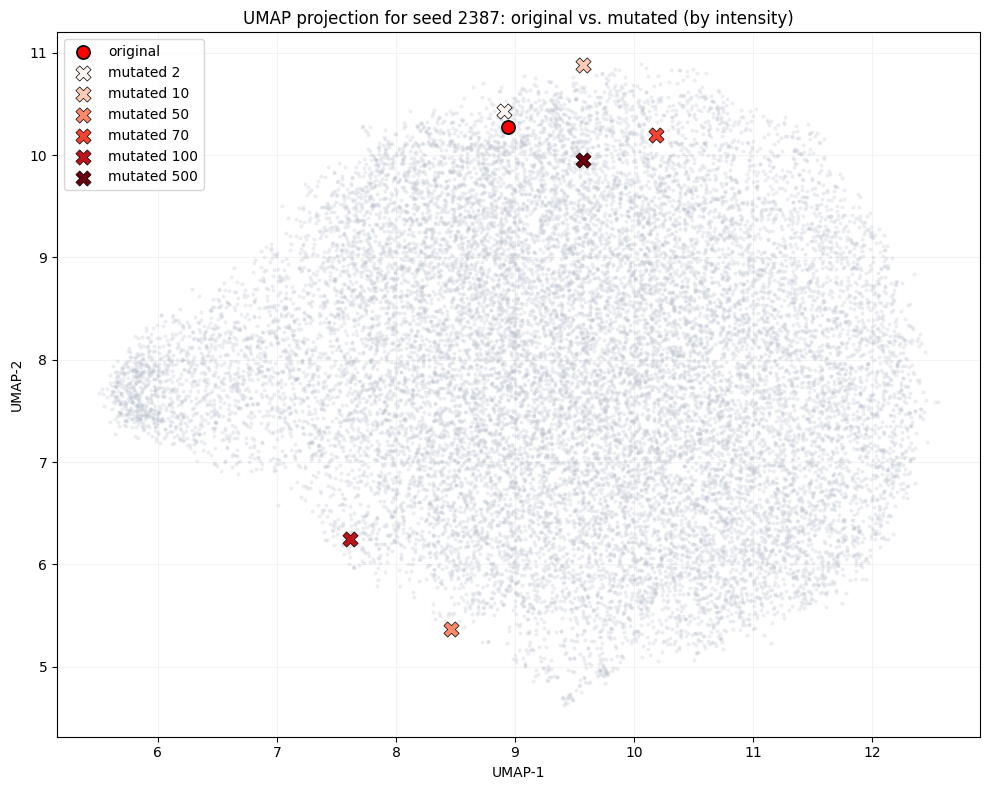

Original_embedding: [[ 1.0929463  -0.33083948 -0.25370267  0.6499578  -1.2206537  -1.0259879
   1.470988   -1.1024593  -0.21902774 -0.8432769  -0.560863   -0.44358215
   0.06820429 -1.6448662   0.12153035 -0.25151622  1.0438701   0.07116853
  -1.09593     0.4156143  -0.04631018 -2.406185   -1.6032503  -0.62376183
   2.281618    0.02756922 -0.30233517 -0.06494682 -1.4204283   0.53411853
   0.5083036   0.44754076]]
Mutated_embedding_2: [[ 1.1138463  -0.2695465  -0.29088655  0.5926264  -1.1172899  -0.99662215
   1.4279491  -1.137425   -0.09499258 -0.8238804  -0.4570137  -0.43477356
  -0.17148107 -1.6128771   0.18819597 -0.10875697  1.0554461  -0.00651388
  -1.1532046   0.27477297 -0.1017691  -2.4850783  -1.6466702  -0.71843904
   2.0614872   0.05559939 -0.30805048 -0.0993948  -1.6020036   0.58548373
   0.5443368   0.34768432]]
Mutated_embedding_10: [[ 1.9311925   0.10234517  0.7856642   0.6028373  -1.2227975  -2.0488982
   1.4247818  -0.75588393  0.3193302  -1.1807265  -0.52030367  0.1559

C:\Users\milob\AppData\Local\Temp\ipykernel_8176\1270772131.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Reds", len(intensities))


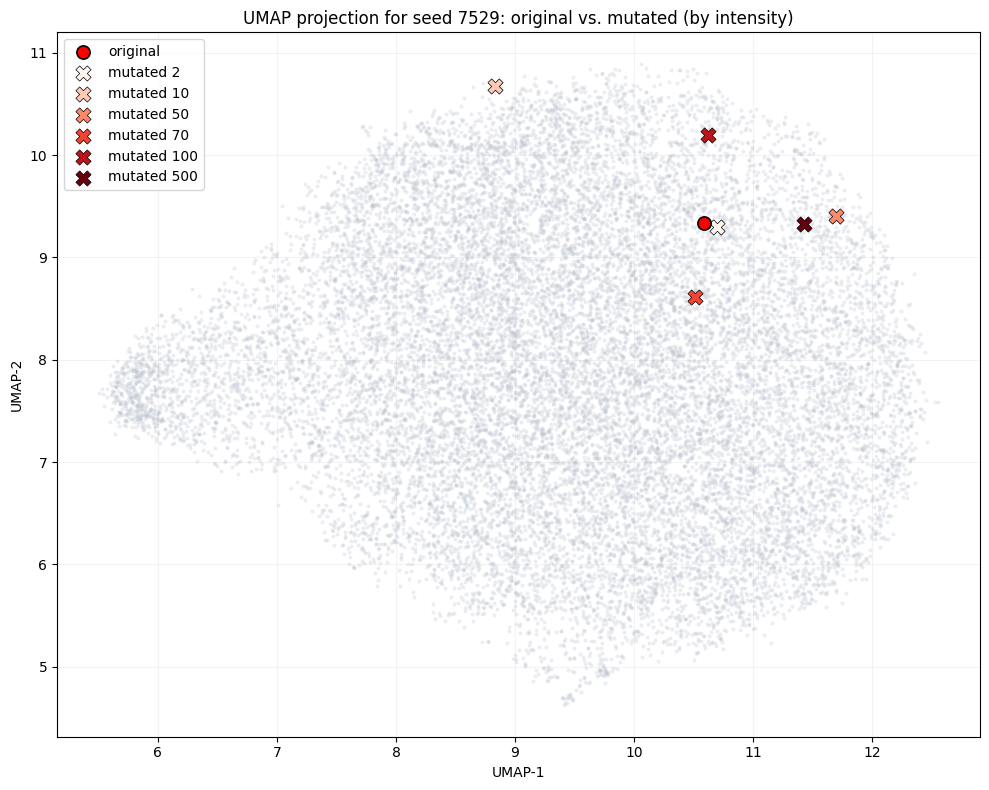

Original_embedding: [[-0.05145895  0.6136902   0.53091633 -0.10101821 -0.29708263  0.8027642
   0.97142303  1.0555315   1.6310467   1.651068    0.29320684  0.70115006
   0.2351237  -1.033127   -0.95811516  0.06944396 -0.8779373   0.02658345
  -0.79027593  0.58588934  1.3378214   0.7901366   0.27001643 -0.22751538
   0.8984773  -0.9995182   0.42965865  0.02640025  0.39062813  0.37092438
  -0.20172499  0.04654058]]
Mutated_embedding_2: [[-0.03430827  0.5748685   0.41513854 -0.21740565  0.01016491  0.7932865
   1.1523718   1.1360288   1.4519686   1.5117693   0.2506407   0.8657503
   0.2044068  -1.1059246  -0.9537882  -0.04159292 -0.76421624 -0.03919566
  -0.9581631   0.45796323  1.3845689   0.9769318   0.00693035 -0.4259907
   0.93592036 -1.0945224   0.5845063  -0.03551931  0.42243624  0.25884327
  -0.05267457  0.12181435]]
Mutated_embedding_10: [[-0.45056897  0.4721133  -0.01392241 -0.1206095  -0.80006546  0.9734715
   0.64173913  0.84729546  1.1577016   1.8919144   0.09199437  0.2489815

C:\Users\milob\AppData\Local\Temp\ipykernel_8176\1270772131.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Reds", len(intensities))


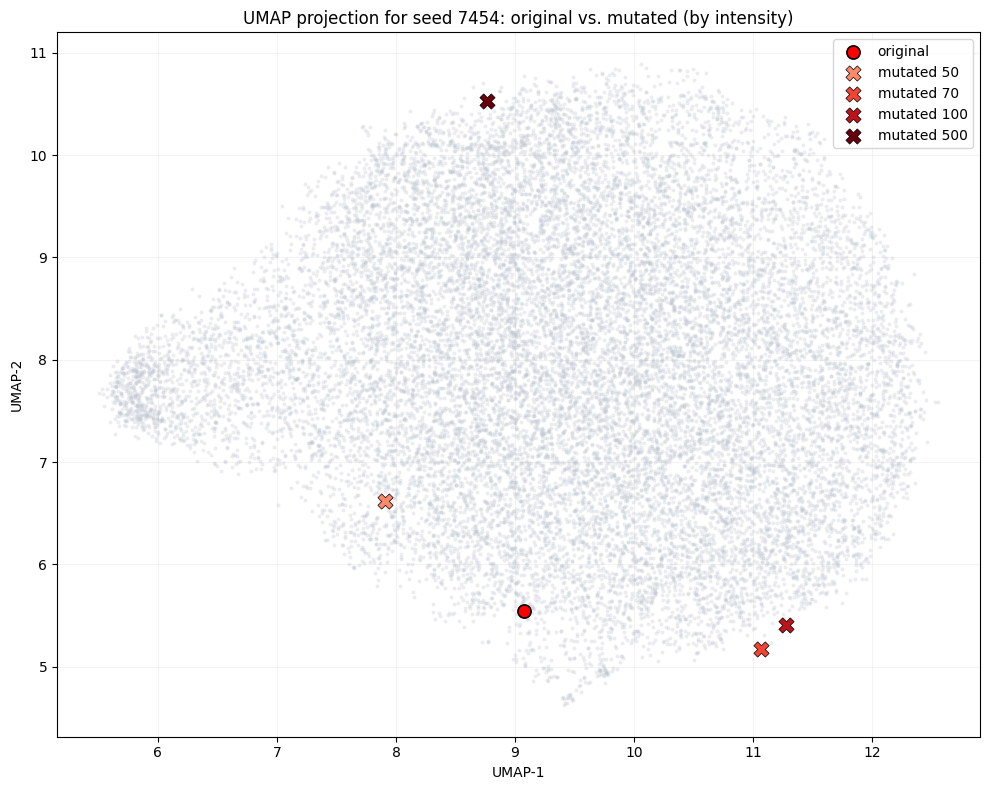

Original_embedding: [[-0.8695845  -1.5333495  -1.0712012  -0.8131513   1.9359207   1.4095994
  -0.16672553  1.0699008  -1.1269689  -1.0286676  -0.13692018 -1.3390781
   0.17213623 -1.2388484   0.14162268 -0.7984955  -1.5358589   0.8239934
  -1.1122655   0.6550901   2.0406585  -0.801846   -1.9649832  -0.789739
   1.1795005   0.7597142  -0.07248695  0.44977385  1.4419805  -1.7302433
  -0.81424725  0.17649826]]
Mutated_embedding_2: None
Mutated_embedding_10: None
Mutated_embedding_50: [[-0.7267983  -0.86552685  0.08237138  0.23206542 -0.35365692 -0.0524946
  -0.05914438 -0.64038783  1.3301473  -0.952223    0.8783617   1.928811
   0.26689118 -0.4962449  -0.569488   -0.3751492   0.8370698  -0.9228113
  -0.93405986 -0.04613119 -0.9705954   0.3433206   0.07192011  0.06302806
  -2.030586   -0.00591725  0.16668537 -0.9909769   0.2745627   1.1653248
  -1.1362582   0.1470235 ]]
Mutated_embedding_70: [[-0.16234009 -2.3517551   0.01931295 -1.1655694   0.9622285  -0.9637475
  -1.6256914  -2.0410028 

In [3]:
import matplotlib.pyplot as plt
from qd.evaluator import EvaluatorMetrics

evaluator = evaluator = EvaluatorMetrics.load_pretrained(EMBEDDING_MODEL_PATH)

def _convert_metrics_to_embedding(metrics_data):
    """Convert raw metric data to VAE embedding."""
    if not metrics_data or len(metrics_data) == 0:
        return None
    metrics_array = np.array(metrics_data)
    embedding = evaluator.measure_from_metrics(metrics_array)
    return np.asarray(embedding).reshape(1, -1)

for seed, payload in results_by_seed.items():
    intensities = payload["intensities"]
    original_embedding = _convert_metrics_to_embedding(payload["original_embedding_data"])

    mutated_embeddings_by_intensity = {
        intensity: _convert_metrics_to_embedding(metrics)
        for intensity, metrics in payload["mutated_embedding_data_by_intensity"].items()
    }

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(
        umap_model.embedding_[:, 0],
        umap_model.embedding_[:, 1],
        s=8,
        c="#b8c0cc",
        alpha=0.28,
        linewidths=0,
        label="_embeddings background",
    )

    legend_handles = []
    legend_labels = []
    if original_embedding is not None:
        original_umap = umap_model.transform(original_embedding)
        original_handle = ax.scatter(
            original_umap[:, 0],
            original_umap[:, 1],
            s=90,
            c="#ff0000",
            edgecolors="black",
            linewidths=1.2,
            label="original",
            zorder=4,
        )
        legend_handles.append(original_handle)
        legend_labels.append("original")

    cmap = plt.cm.get_cmap("Reds", len(intensities))
    mutated_handles = {}
    for idx, intensity in enumerate(intensities):
        embedding = mutated_embeddings_by_intensity.get(intensity)
        if embedding is None:
            continue
        color = cmap(idx)
        mutated_umap = umap_model.transform(embedding)
        mutated_handles[intensity] = ax.scatter(
            mutated_umap[:, 0],
            mutated_umap[:, 1],
            s=120,
            c=[color],
            marker="X",
            edgecolors="black",
            linewidths=0.5,
            label=f"mutated {intensity}",
            zorder=3,
        )

    for intensity in intensities:
        handle = mutated_handles.get(intensity)
        if handle is None:
            continue
        legend_handles.append(handle)
        legend_labels.append(f"mutated {intensity}")

    ax.set_title(f"UMAP projection for seed {seed}: original vs. mutated (by intensity)")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(legend_handles, legend_labels, frameon=True)
    ax.grid(alpha=0.15)
    plt.tight_layout()
    plt.show()

    print("Original_embedding:", original_embedding)
    for intensity in intensities:
        print(f"Mutated_embedding_{intensity}:", mutated_embeddings_by_intensity.get(intensity))

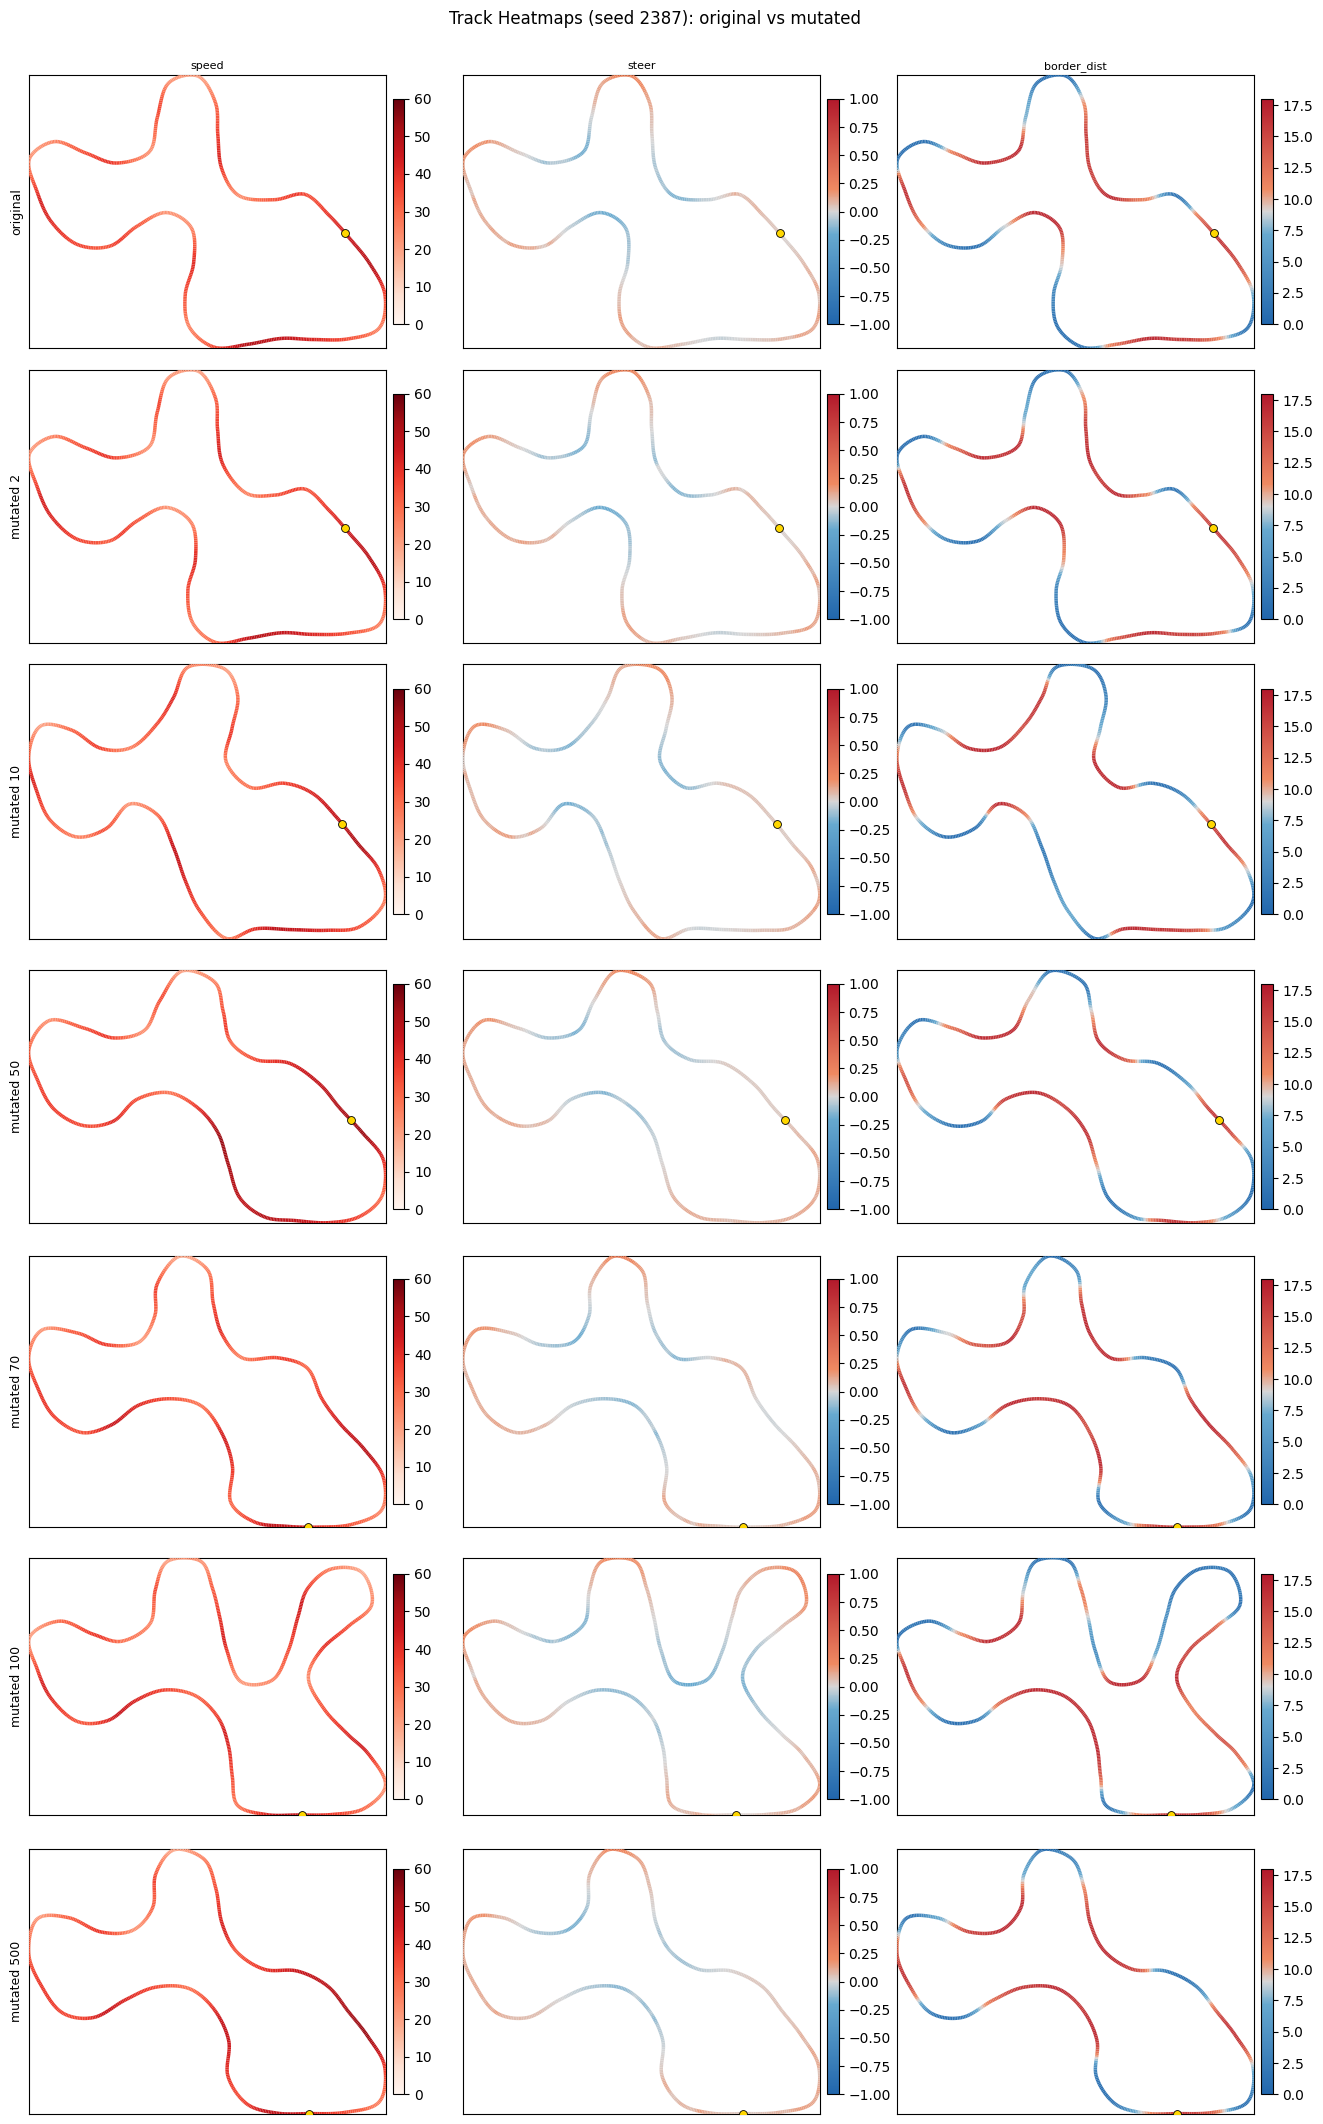

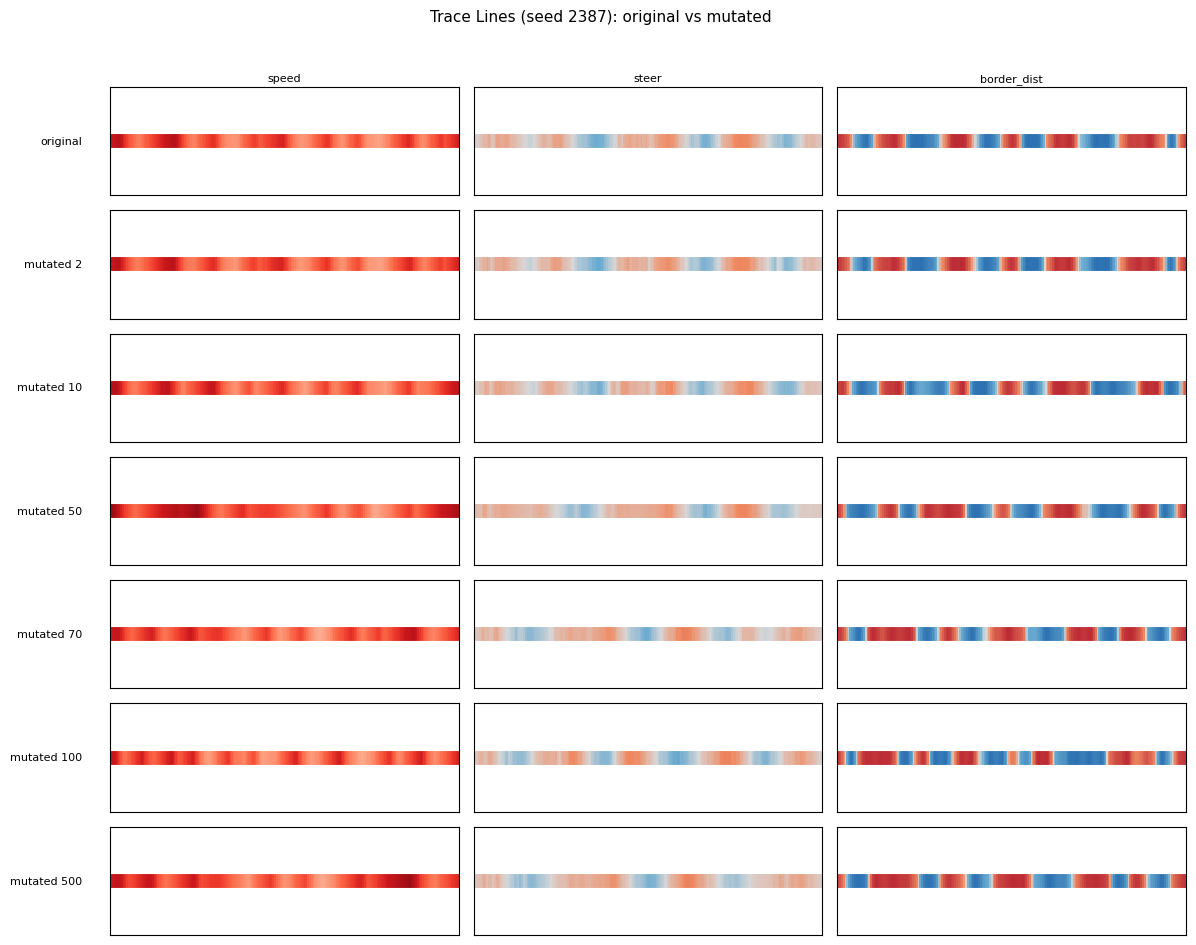

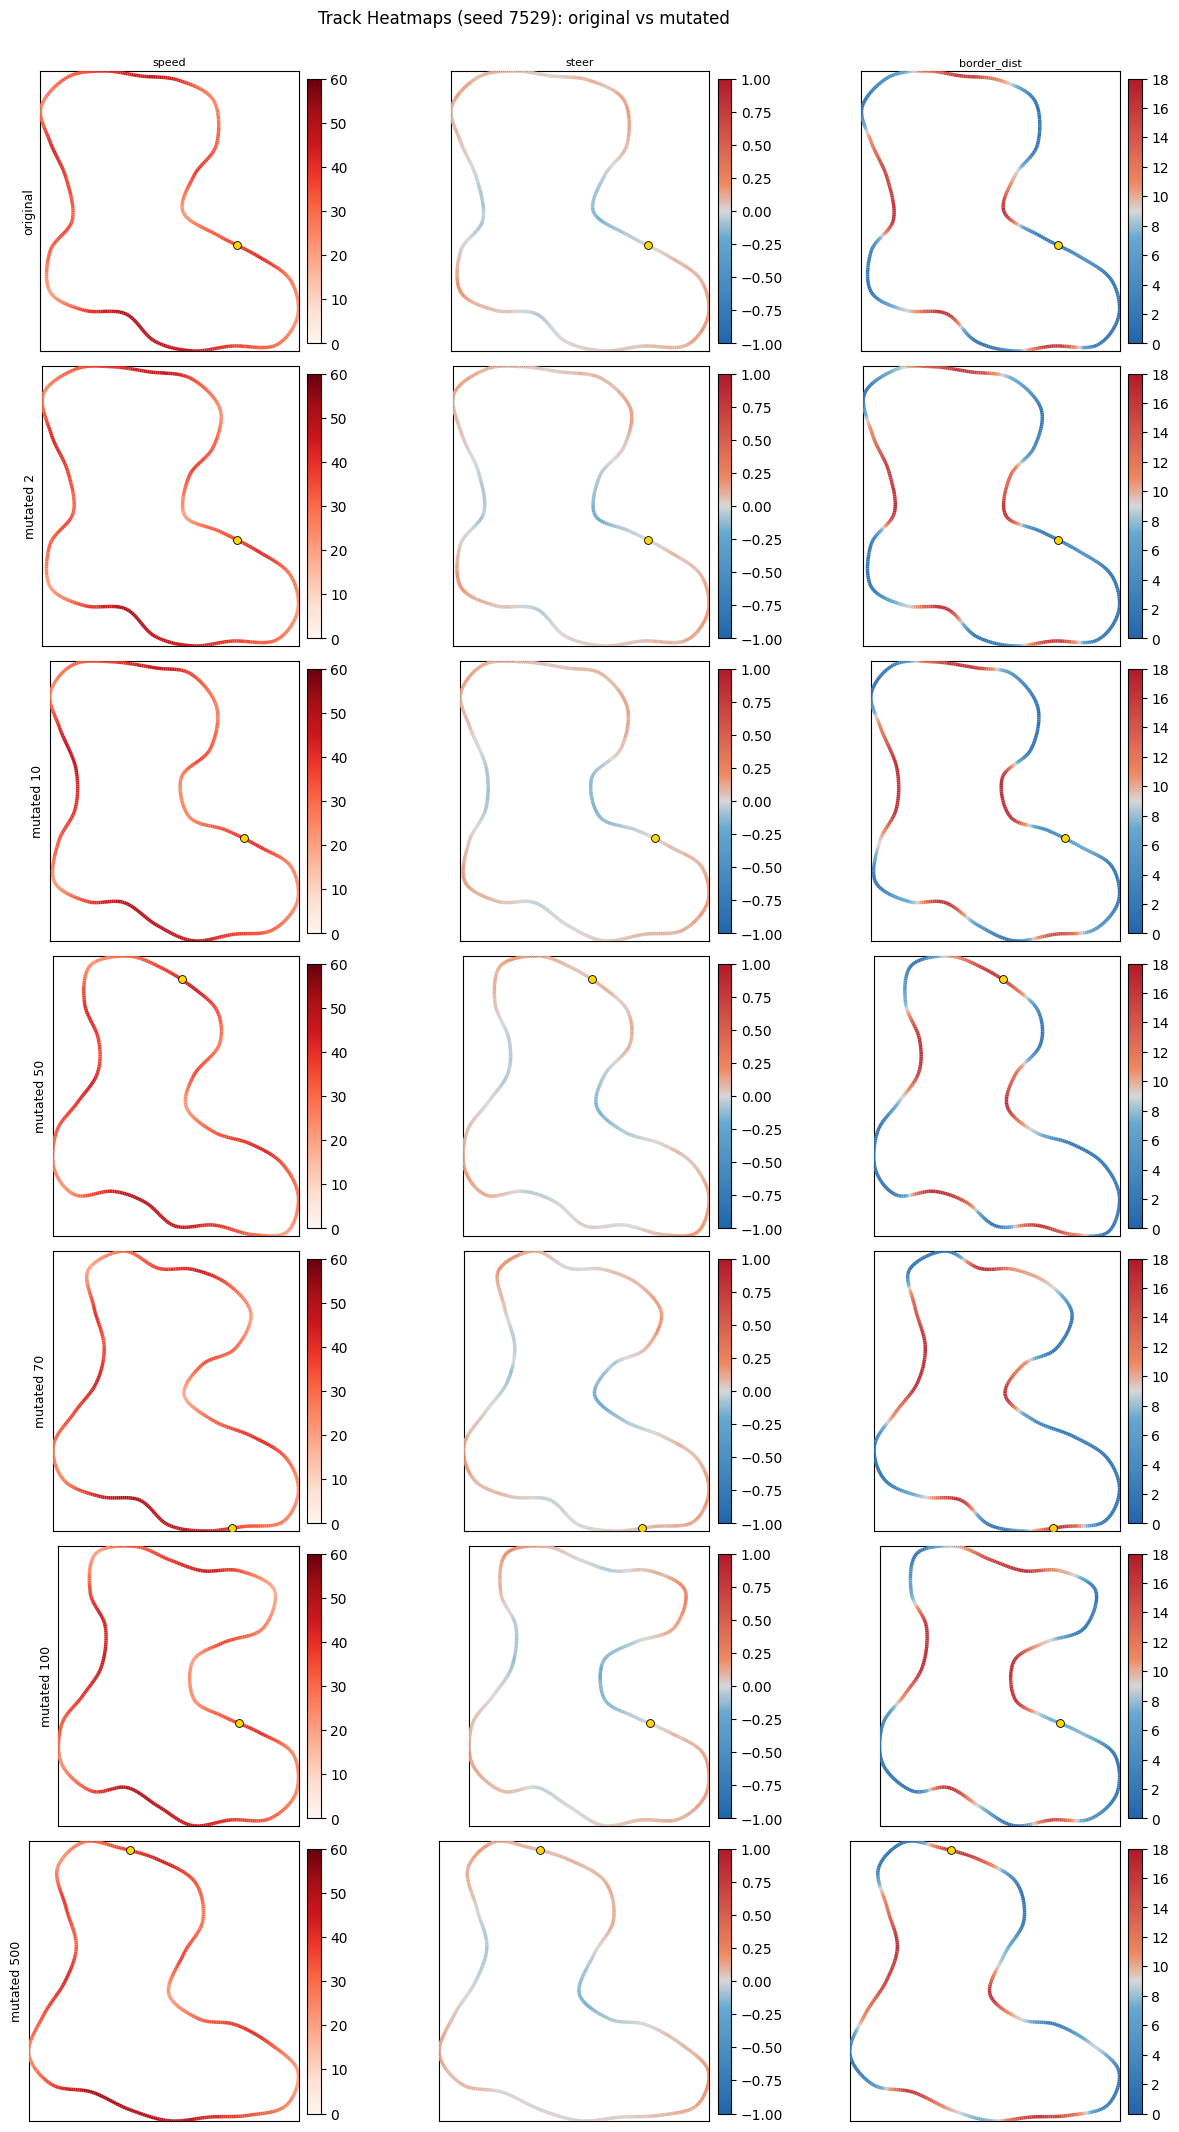

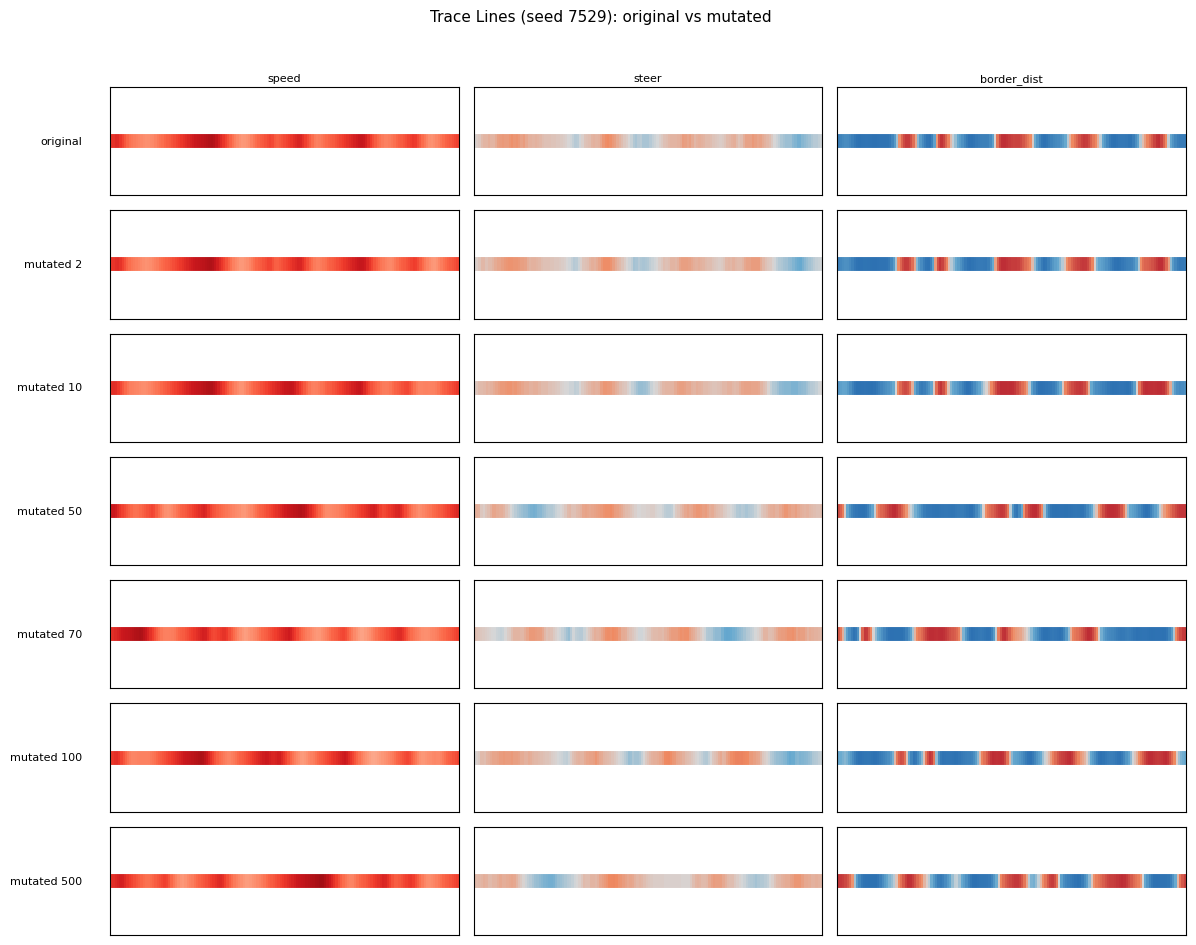

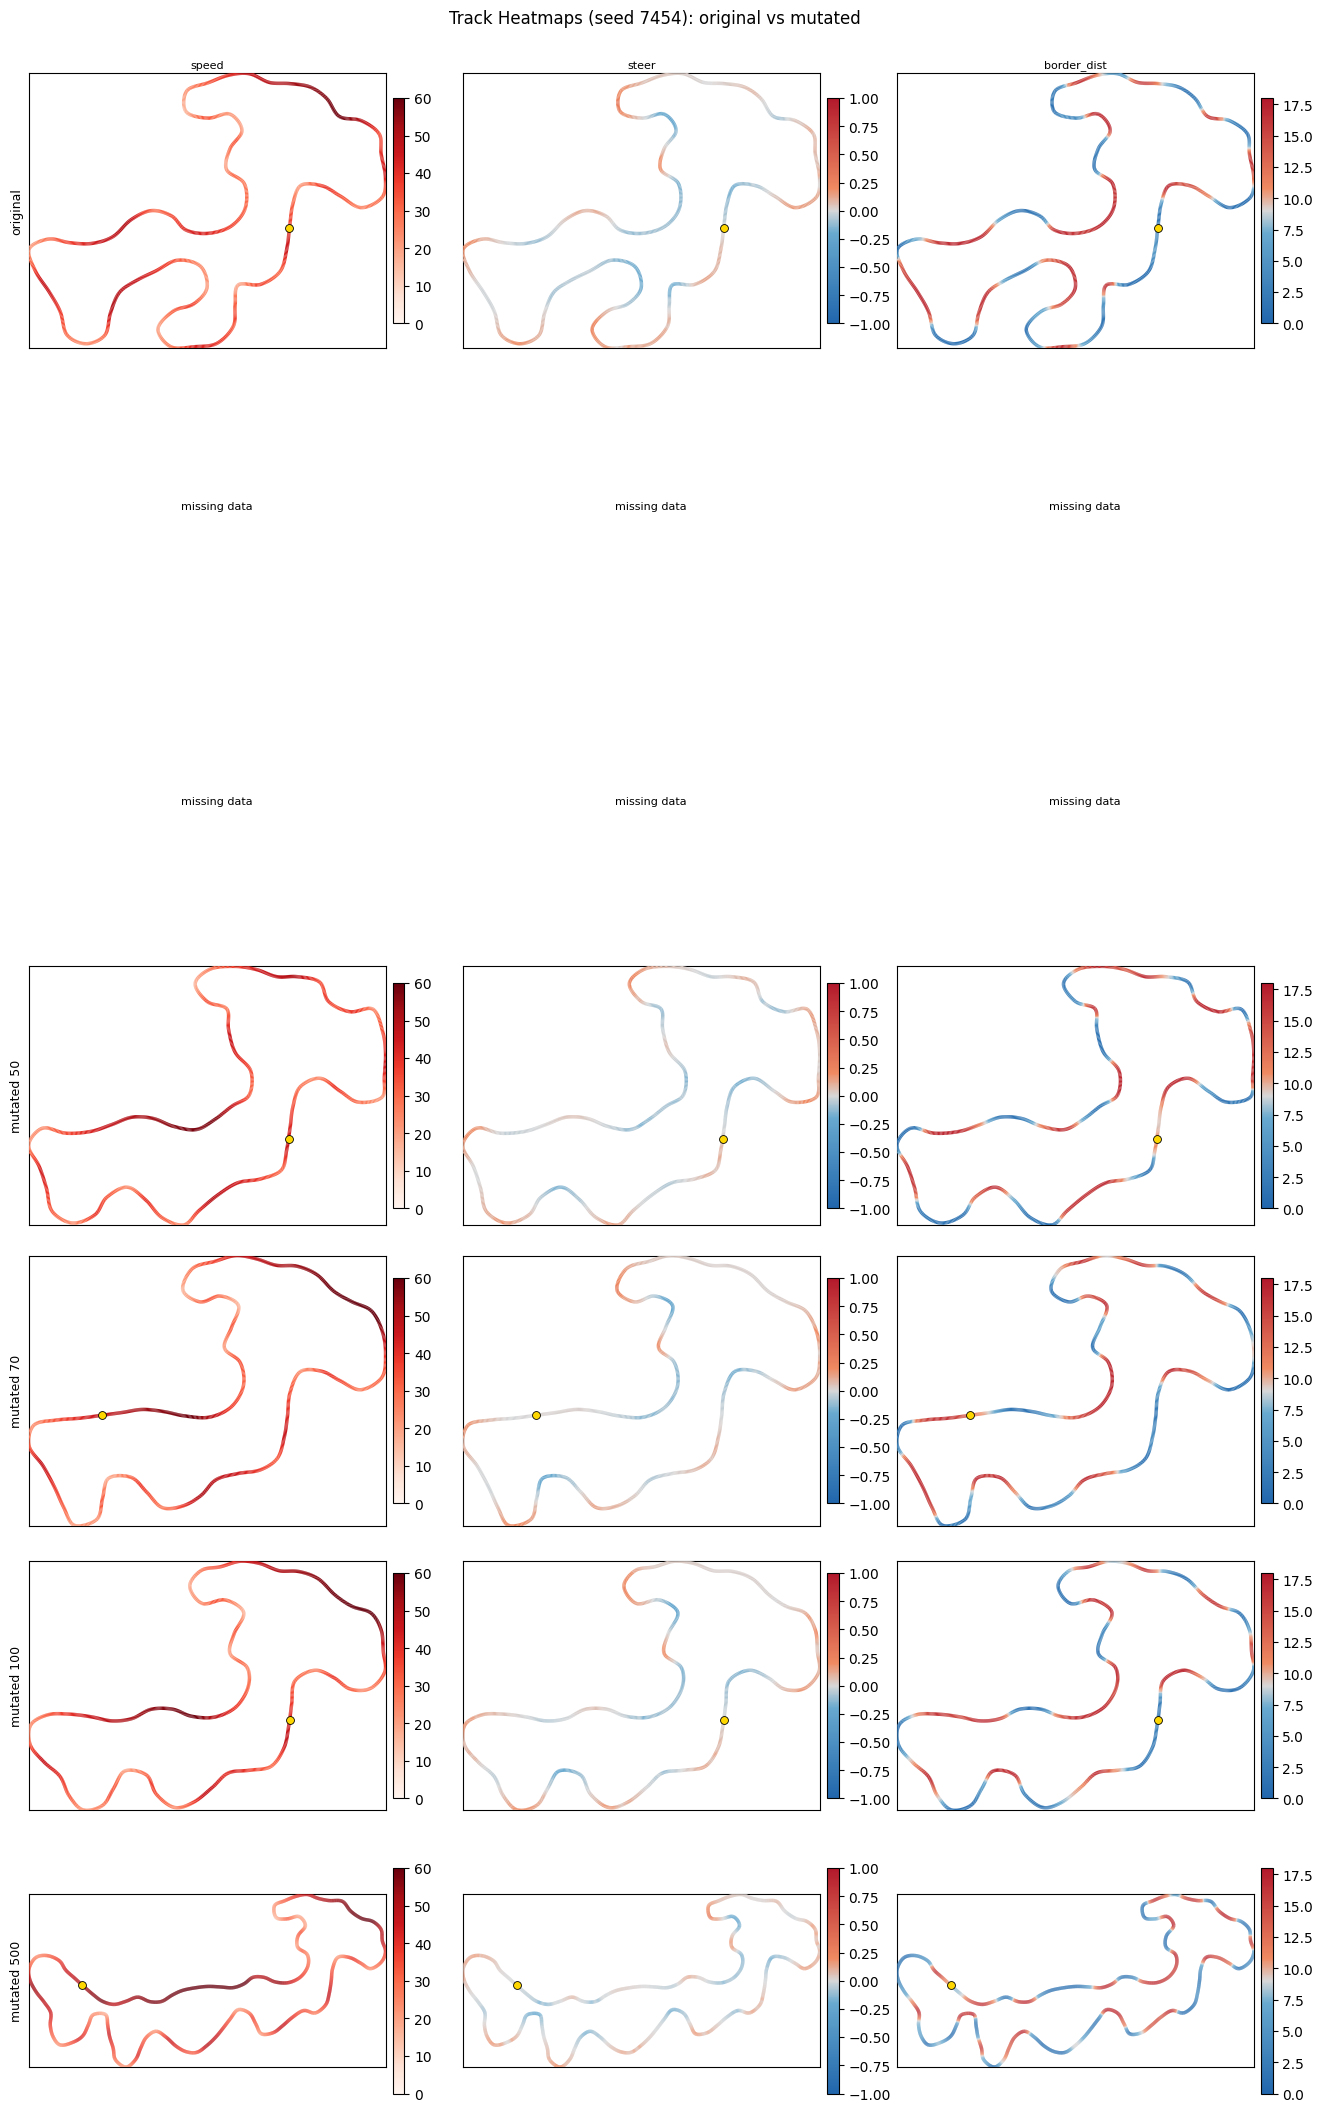

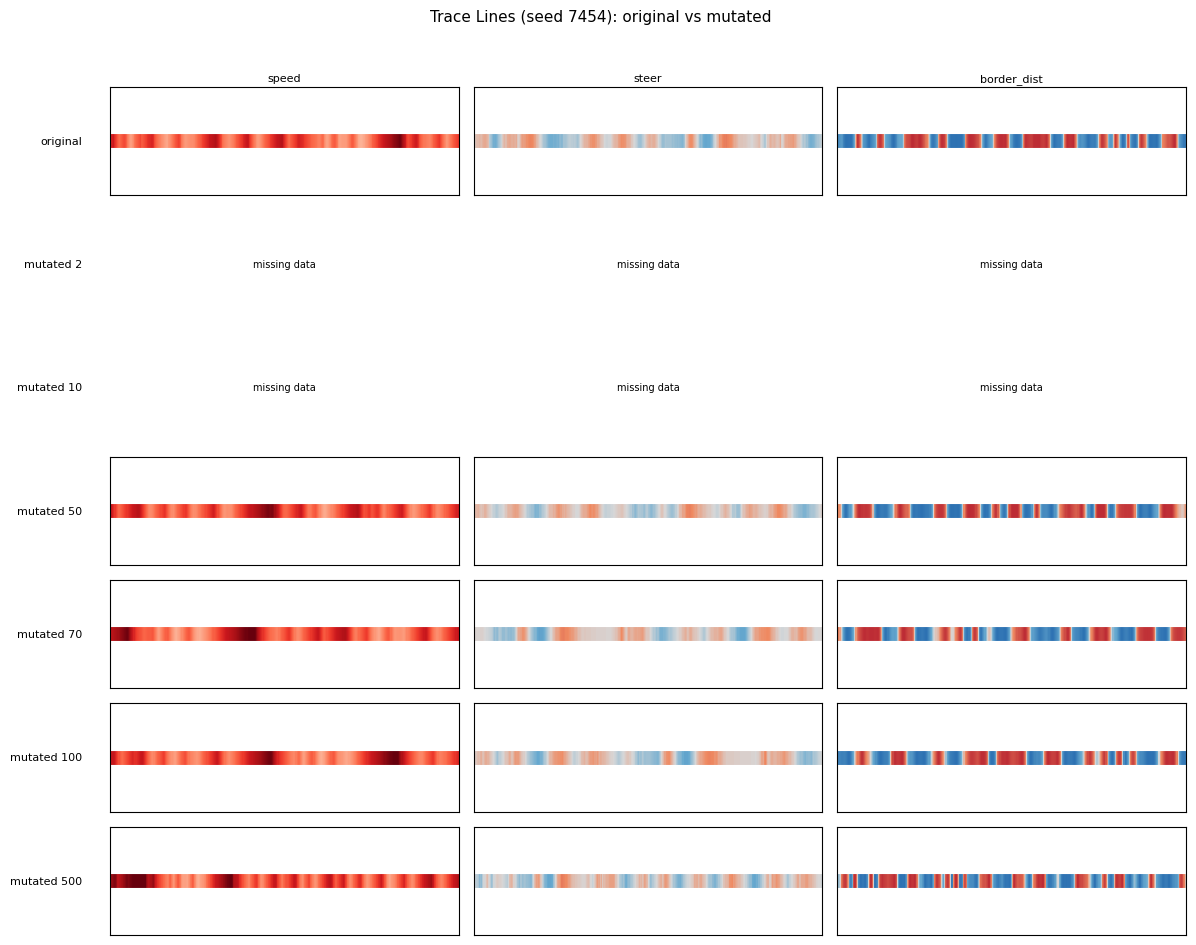

In [4]:
import math
import importlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import qd.analysis.utils as analysis_utils
importlib.reload(analysis_utils)

from qd.analysis.utils import (
    plot_track,
    plot_track_heatmap,
    plot_trace_fixed_line,
)

HEATMAP_METRICS = ["speed_trace", "steer_trace", "border_dist_trace"]
HEATMAP_RANGES = {
    "speed_trace": (0, 60),
    "steer_trace": (-1, 1),
    "accel_trace": (0, 1),
    "brake_trace": (0, 1),
    "border_dist_trace": (0, 18),
}

CUSTOM_BURD = LinearSegmentedColormap.from_list(
    "custom_burd",
    [
        (0.0, (33 / 255.0, 102 / 255.0, 172 / 255.0)),
        (0.4, (103 / 255.0, 169 / 255.0, 207 / 255.0)),
        (0.5, (215 / 255.0, 215 / 255.0, 215 / 255.0)),
        (0.6, (239 / 255.0, 138 / 255.0, 98 / 255.0)),
        (1.0, (178 / 255.0, 24 / 255.0, 43 / 255.0)),
    ],
    N=256,
)

HEATMAP_CMAPS = {
    "speed_trace": "Reds",
    "accel_trace": "Reds",
    "steer_trace": CUSTOM_BURD,
    "brake_trace": "Reds",
    "border_dist_trace": CUSTOM_BURD,
}

LINE_METRICS = ["speed_trace", "steer_trace", "border_dist_trace"]
LINE_RANGES = {
    "speed_trace": (0, 60),
    "steer_trace": (-1, 1),
    "border_dist_trace": (0, 18),
}
LINE_CMAPS = {
    "speed_trace": "Reds",
    "steer_trace": CUSTOM_BURD,
    "border_dist_trace": CUSTOM_BURD,
}

def _clean_trace(trace):
    if not trace:
        return []
    arr = np.asarray(trace, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 2:
        return []
    values = arr[:, 0]
    distances = arr[:, 1]
    finite = np.isfinite(values) & np.isfinite(distances)
    values, distances = values[finite], distances[finite]
    if len(values) < 2:
        return []
    return list(zip(values.tolist(), distances.tolist()))

def _extract_trace_values(trace):
    if not trace:
        return np.array([])
    arr = np.asarray(trace, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 1:
        return np.array([])
    values = arr[:, 0]
    values = values[np.isfinite(values)]
    return values

def _plot_start_point(ax, track):
    if not track:
        return
    start = track[0]
    sx, sy = start.get("x"), start.get("y")
    if sx is None or sy is None:
        return
    ax.scatter(
        [sx],
        [sy],
        s=32,
        c="gold",
        edgecolors="black",
        linewidths=0.6,
        zorder=10,
        marker="o",
    )

for seed, payload in results_by_seed.items():
    intensities = payload["intensities"]
    items = [("original", payload["original_track"], payload["original_traces"])]
    for intensity in intensities:
        items.append(
            (
                f"mutated {intensity}",
                payload["mutated_tracks_by_intensity"].get(intensity),
                payload["mutated_traces_by_intensity"].get(intensity, {}),
            )
        )

    if len(items) == 0:
        print(f"No track data found for seed {seed}. Run Cell 2 first.")
        continue

    # Heatmaps over track geometry
    nrows = len(items)
    ncols = len(HEATMAP_METRICS)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.4 * ncols, 3.1 * nrows),
        squeeze=False,
    )

    for r, (label, track, traces) in enumerate(items):
        for c, metric in enumerate(HEATMAP_METRICS):
            ax = axes[r, c]
            metric_trace = _clean_trace((traces or {}).get(metric))
            metric_label = metric.replace("_trace", "")

            if track and metric_trace:
                plot_track_heatmap(
                    ax,
                    track,
                    metric_trace,
                    title=metric_label if r == 0 else None,
                    cmap=HEATMAP_CMAPS.get(metric, "Reds"),
                    color_range=HEATMAP_RANGES.get(metric),
                )
                _plot_start_point(ax, track)
            else:
                if track:
                    plot_track(ax, track, title=metric_label if r == 0 else None, track_color="lightgray")
                    _plot_start_point(ax, track)
                else:
                    ax.set_axis_off()
                ax.text(
                    0.5,
                    0.5,
                    "missing data",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=8,
                )

            if c == 0:
                ax.set_ylabel(label, fontsize=9)

    fig.suptitle(f"Track Heatmaps (seed {seed}): original vs mutated", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

    # Linear trace summary
    ncols = len(LINE_METRICS)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.0 * ncols, 1.2 * nrows + 1.2),
        squeeze=False,
    )

    for r, (label, _track, traces) in enumerate(items):
        for c, metric in enumerate(LINE_METRICS):
            ax = axes[r, c]
            values = _extract_trace_values((traces or {}).get(metric))
            title = metric.replace("_trace", "")
            if values.size >= 2:
                plot_trace_fixed_line(
                    ax,
                    values,
                    line_length=1.0,
                    y=0.0,
                    title=title if r == 0 else None,
                    cmap=LINE_CMAPS.get(metric, "Reds"),
                    color_range=LINE_RANGES.get(metric),
                    linewidth=10,
                    show_colorbar=False,
                )
            else:
                ax.set_axis_off()
                if r == 0:
                    ax.set_title(title, fontsize=8, pad=4)
                ax.text(
                    0.5,
                    0.5,
                    "missing data",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=7,
                )

            if c == 0:
                ax.text(
                    -0.08,
                    0.5,
                    label,
                    transform=ax.transAxes,
                    ha="right",
                    va="center",
                    fontsize=8,
                )

    fig.suptitle(f"Trace Lines (seed {seed}): original vs mutated", fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()